In [1]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.iv import compare
from linearmodels.panel.results import compare
import statsmodels.api as sm
from statsmodels.api import qqplot
from linearmodels.panel import PanelOLS
from scipy import stats as scipy_stats

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from tqdm.notebook import tqdm
from itables import init_notebook_mode
# init_notebook_mode()

# working pop preparations

In [2]:
additional_health_variables = pl.read_excel('../data/disease_variables.xlsx')
additional_health_variables

var,label,fill
str,str,str
"""m20_61""","""chronic_heart""","""no"""
"""m20_62""","""chronic_lung""","""no"""
"""m20_63""","""chronic_liver""","""no"""
"""m20_64""","""chronic_kidney""","""no"""
"""m20_65""","""chronic_stomach""","""no"""
"""m20_66""","""chronic_spinal""","""no"""
"""m20_612""","""disease_neuro""","""no"""
"""m20_613""","""disease_eye""","""no"""
"""m20_615""","""allegies""","""no"""


In [3]:
cols_disease = additional_health_variables['var'].to_list()
cols_disease

['m20_61',
 'm20_62',
 'm20_63',
 'm20_64',
 'm20_65',
 'm20_66',
 'm20_612',
 'm20_613',
 'm20_615',
 'm20_8']

In [4]:
cols = ['idind', 'year', 'h7_2', 'h7_1', 'origsm', 'region', 'psu', 'status', 'age', 'educ', 'marst', 'h5', 'm20_7', 'j1', 'j60', 'j40', 'j363']

In [5]:
cols + cols_disease

['idind',
 'year',
 'h7_2',
 'h7_1',
 'origsm',
 'region',
 'psu',
 'status',
 'age',
 'educ',
 'marst',
 'h5',
 'm20_7',
 'j1',
 'j60',
 'j40',
 'j363',
 'm20_61',
 'm20_62',
 'm20_63',
 'm20_64',
 'm20_65',
 'm20_66',
 'm20_612',
 'm20_613',
 'm20_615',
 'm20_8']

In [6]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet', columns=cols + cols_disease)
for var, label, fill in zip(additional_health_variables['var'], additional_health_variables['label'], additional_health_variables['fill']):
    panel = panel.with_columns(
        pl.col(var).fill_null(fill).alias(label)
    )
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no"""
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no"""
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group"""
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no"""
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no"""
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no"""
59409.0,2024.0,"""October""",11.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",53.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""MALE""","""No""","""You are not working""",0.0,null,null,"""No""","""No""","""No""","""No""","""No""","""Y

In [7]:
panel = panel.with_columns(
    date = pl.concat_str([pl.col('year').cast(pl.Int32), pl.col('h7_2'), pl.col('h7_1').cast(pl.Int32)], separator=' ').str.strptime(pl.Date, format='%Y %B %d')
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09
59409.0,2024.0,"""October""",11.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",53.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""MALE""","""No""",

In [8]:
panel = panel.with_columns(
    is_employed = pl.when(pl.col('j1').is_in(['You are currently working', 'You are on paid leave: maternity leave or taking care of a child under 3 years o', 'You are on another kind of paid leave'])).then(1).otherwise(0)
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0
59409.0,2024.0,"""October""",11.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",53.0,"""10 and more grades of school &…","""Divorsed and not r

In [9]:
panel = panel.with_columns(
    has_disablity = pl.when(pl.col('m20_7').is_in(['No', 'NO ANSWER'])).then(0).otherwise(1)
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0,0
59409.0,2024.0,"""October""",11.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",53.0,"""10 and more grades o

In [10]:
panel = panel.with_columns(
    is_employed_has_disablity = pl.col('is_employed') * pl.col('has_disablity')
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0,0
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0,0,0
59409.0,2024.0,"""October""",11.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Ob

In [11]:
panel = panel.with_columns(
    is_employed_no_disablity = pl.col('is_employed') * pl.col('has_disablity').replace({0:1, 1:0})
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0,1
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0,0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0,0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0,0,1
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0,0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0,0,0,0
59409.0,2024.0,"""October""",11.0,"""Yes, it is an adress from

In [12]:
panel = panel.with_columns(
    net_job = pl.col('j60').fill_null(0) - pl.col('j363').fill_null(0)
)
panel = panel.with_columns(
    pl.when(pl.col('net_job') < 0).then(0).otherwise('net_job').alias('net_job')
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0,1,30000.0
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0,0,800.0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0,0,0.0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0,0,1,7000.0
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0,1,4500.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0,0,0.0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0,0,0,0,0.0
59409.0,

In [13]:
panel  = panel.filter(pl.col('net_job') < 1_000_000)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0,1,30000.0
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0,0,800.0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0,0,0.0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0,0,1,7000.0
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0,1,4500.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0,0,0.0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0,0,0,0,0.0
59409.0,

In [14]:
(
    panel
        .filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
)#.plot.line(x='year', y='net_job', color='has_disablity')

year,has_disablity,net_job
date,i32,f64
2016-01-01,1,19265.172575
2021-01-01,0,35950.469144
2019-01-01,0,31292.488262
2017-01-01,0,27265.28691
2014-01-01,0,24772.844037
…,…,…
2024-01-01,1,42800.563758
2022-01-01,0,38747.190139
2022-01-01,1,32208.307086


In [15]:
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0,1,30000.0
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0,0,800.0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0,0,0.0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0,0,1,7000.0
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0,1,4500.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0,0,0.0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2024-10-09,0,0,0,0,0.0
59409.0,

In [16]:

len(panel.unique('idind'))

30977

In [17]:
panel = panel.with_columns(
    working_pop = pl.when((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1)).then(1).otherwise(0)
)
panel

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job,working_pop
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0,1,30000.0,1
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0,0,800.0,0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0,0,0.0,0
34908.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",58.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",7000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-18,1,0,0,1,7000.0,1
34919.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",4500.0,null,null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0,1,4500.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0,0,0.0,0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2

In [18]:
panel_working_pop_2019 = panel.filter(
    #pl.col('date').is_between(pl.date(2019, 1, 1), pl.date(2019, 12, 31))
    pl.col('year') == 2019
)
panel_working_pop_2019

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job,working_pop
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64,i32
1.0,2019.0,"""October""",11.0,"""No, it is not belong to the re…","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",46.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""No""","""You are currently working""",37000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2019-10-11,1,0,0,1,37000.0,1
7.0,2019.0,"""October""",9.0,"""Yes, it is an adress from the …","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",75.0,"""7-9 grades of school [unfinish…","""Never married""","""FEMALE""","""Yes""","""You are not working""",16374.0,null,15424.0,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""","""Third group""","""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""","""Third group""",2019-10-09,0,1,0,0,950.0,0
9.0,2019.0,"""November""",13.0,"""Yes, it is an adress from the …","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",73.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",16000.0,null,16000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2019-11-13,0,0,0,0,0.0,0
11292.0,2019.0,"""October""",15.0,"""No, it is not belong to the re…","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",77.5,"""Technical, medical, musis etc …","""Widower or widow""","""FEMALE""","""Yes""","""You are not working""",14689.0,null,12989.0,"""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Second group""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Second group""",2019-10-15,0,1,0,0,1700.0,0
3.0,2019.0,"""October""",9.0,"""Yes, it is an adress from the …","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",64.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""Yes""","""You are currently working""",38100.0,null,17500.0,"""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""No""","""Third group""",2019-10-09,1,1,1,0,20600.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59409.0,2019.0,"""January""",23.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",48.5,"""10 and more grades of school &…","""Widower or widow""","""MALE""","""No""","""You are not working""",0.0,null,null,"""Yes""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""no""",2019-01-23,0,0,0,0,0.0,0
59410.0,2019.0,"""January""",28.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""town""",70.5,"""9 grades of school""","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",46000.0,null,17000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No"""

In [19]:
panel_working_pop_2020 = panel.filter(
    #pl.col('date').is_between(pl.date(2020, 1, 1), pl.date(2020, 12, 31))
    pl.col('year') == 2020
)
panel_working_pop_2020

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job,working_pop
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64,i32
1.0,2020.0,"""October""",13.0,"""No, it is not belong to the re…","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",47.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""No""","""You are currently working""",37000.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2020-10-13,1,0,0,1,37000.0,1
7.0,2020.0,"""October""",8.0,"""Yes, it is an adress from the …","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",76.0,"""7-9 grades of school [unfinish…","""Never married""","""FEMALE""","""Yes""","""You are not working""",17376.0,null,17376.0,"""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Second group""","""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Second group""",2020-10-08,0,1,0,0,0.0,0
9.0,2020.0,"""October""",28.0,"""Yes, it is an adress from the …","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",74.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",22000.0,null,22000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2020-10-28,0,0,0,0,0.0,0
11292.0,2020.0,"""November""",11.0,"""No, it is not belong to the re…","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",78.5,"""Technical, medical, musis etc …","""Widower or widow""","""FEMALE""","""Yes""","""You are not working""",32550.0,null,16750.0,"""Yes""","""No""","""Yes""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Second group""","""Yes""","""No""","""Yes""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Second group""",2020-11-11,0,1,0,0,15800.0,0
3.0,2020.0,"""October""",9.0,"""Yes, it is an adress from the …","""Leningrad Oblast: Volosovkij R…","""Volosovkij Rajon: Leningradska…","""PGT""",65.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""Yes""","""You are not working""",19700.0,null,19000.0,"""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""No""","""Third group""",2020-10-09,0,1,0,0,700.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59408.0,2020.0,"""September""",12.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",69.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",11660.0,null,10660.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2020-09-12,0,0,0,0,1000.0,0
59409.0,2020.0,"""September""",12.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""MALE""","""No""","""You are not working""",0.0,null,null,"""No""","""No""","""No""","""No""","""No""",null,"""No""",null,"""No""",null,

In [20]:
panel_working_pop_2020['status'].value_counts()

status,count
str,u32
"""town""",4563
"""rural""",4350
"""PGT""",1246
"""oblastnoy center""",7541


In [21]:
common_people = panel_working_pop_2019[['idind']].join(panel_working_pop_2020[['idind']], how='inner', on='idind').unique()
common_people

idind
f64
47833.0
16719.0
51730.0
25909.0
16949.0
…
58600.0
28894.0
10851.0


In [22]:
len(common_people)

16038

In [23]:
len(common_people.unique())

16038

In [24]:
panel_common_2019_2020 = panel.filter(
    pl.col('idind').is_in(common_people['idind'].implode())
)
panel_common_2019_2020

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,m20_61,m20_62,m20_63,m20_64,m20_65,m20_66,m20_612,m20_613,m20_615,m20_8,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job,working_pop
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,date,i32,i32,i32,i32,f64,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,1,0,0,1,30000.0,1
34897.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",62.5,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",14000.0,null,13200.0,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-05,0,0,0,0,800.0,0
34907.0,2014.0,"""January""",18.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",54.0,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""Yes""","""You are not working""",7000.0,null,7000.0,"""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""","""No""","""No""","""No""","""No""","""No""","""Yes""","""No""","""No""","""No""","""Third group""",2014-01-18,0,1,0,0,0.0,0
34920.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",8200.0,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2014-01-19,1,0,0,1,8200.0,1
34925.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",52.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are not working""",7200.0,null,5900.0,"""No""","""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""",null,"""No""","""Yes""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""no""",2014-01-19,0,0,0,0,1300.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59407.0,2024.0,"""November""",27.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",8.0,null,null,"""FEMALE""","""No""",null,null,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""no""",2024-11-27,0,0,0,0,0.0,0
59408.0,2024.0,"""October""",9.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",73.0,"""Secondary School Diploma""","""Widower or widow""","""FEMALE""","""No""","""You are not working""",31000.0,null,31000.0,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""no""",2

In [25]:
panel_common_2019_2020['h7_2'].value_counts()

h7_2,count
str,u32
"""February""",1
"""November""",44919
"""October""",65755
"""January""",2718
"""September""",11654
"""December""",13396


In [26]:
len(panel_common_2019_2020)

138443

In [27]:
# panel_common_2019_2020.write_parquet('../data/panel_common_2019_2020.parquet')

In [29]:
panel_common_2019_2020.filter(
    pl.col('is_employed_no_disablity') == 1
).group_by('year').len().plot.line(x='year', y='len')

alt.Chart(...)

In [30]:
panel_common_2019_2020.filter(
    pl.col('is_employed_has_disablity') == 1
).group_by('year').len().plot.line(x='year', y='len')

alt.Chart(...)

In [31]:
(
    panel_common_2019_2020
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .filter(pl.col('working_pop') == 1)
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='has_disablity')

alt.Chart(...)

In [36]:
alt.data_transformers.enable("vegafusion")
#panel_common_2019_2020.filter(pl.col('h7_2').is_in(['October', 'November', 'December'])).plot.line(x='date', y='net_job', color='has_disablity')

DataTransformerRegistry.enable('vegafusion')

In [33]:
(
    panel_common_2019_2020
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('working_pop') == 1)
        .filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
)#.plot.line(x='year', y='net_job', color='has_disablity')

alt.Chart(...)

In [37]:
len(panel_common_2019_2020.unique('idind'))

16038

In [38]:
did_data = panel_common_2019_2020.filter(pl.col('working_pop') == 1).filter(
    (pl.col('year').is_in([2017, 2018 ,2019, 2020]))
)[['idind', 'year', 'net_job', 'is_employed_has_disablity']].to_pandas().set_index(['idind', 'year'])
did_data.sort_index()

net_job  is_employed_has_disablity
idind   year                                      
1.0     2017.0   4000.0                          0
        2018.0  47000.0                          0
        2019.0  37000.0                          0
        2020.0  37000.0                          0
3.0     2017.0  20000.0                          1
...                 ...                        ...
59395.0 2020.0  32000.0                          0
59398.0 2019.0  30000.0                          0
        2020.0  29000.0                          0
59400.0 2019.0  12000.0                          0
        2020.0   9200.0                          0

[26408 rows x 2 columns]

In [39]:
X_agg = did_data[['is_employed_has_disablity']]
y = did_data['net_job']

In [40]:
agg_did_model = PanelOLS(y, X_agg, entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(agg_did_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                     2.516e-05
Estimator:                   PanelOLS   R-squared (Between):             -0.0017
No. Observations:               26408   R-squared (Within):            2.516e-05
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0013
Time:                        17:19:34   Log-likelihood                -2.905e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.4635
Entities:                        7987   P-value                           0.4960
Avg Obs:                       3.3064   Distribution:                 F(1,18420)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             1.5892
                            

# psm

In [41]:
education_levels = pl.read_excel('../data/all_education_levels.xlsx', sheet_name='selected_levels')
education_levels

educ,educ_level
str,str
"""1-2 years in Institute, Univer…","""university"""
"""7 grades of school""","""school_or_less"""
"""6 grades of school""","""school_or_less"""
"""3 grades of school""","""school_or_less"""
"""7-9 grades of school [unfinish…","""common"""
…,…
"""7-9 grades of school [unfinish…","""common"""
"""Graduate school, residency wit…","""common"""
"""10 and more grades of school &…","""higher"""


In [42]:
marital_status = pl.read_excel('../data/all_marst_levels.xlsx', sheet_name='selected_levels')
marital_status

marst,is_married
str,i64
"""In a registered marriage""",1
"""Divorsed and not remarried""",0
"""Living together, not registere…",1
"""Registered, not living togethe…",1
"""Never married""",0
"""Widower or widow""",0


In [43]:
period_relevance = pl.read_excel('../data/period_relevance.xlsx').with_columns(
    pl.col('year').cast(pl.Float64)
)
period_relevance

year,period_relevance
f64,i64
2014.0,-6
2015.0,-5
2016.0,-4
2017.0,-3
2018.0,-2
…,…
2020.0,0
2021.0,1
2022.0,2


In [44]:
is_town = pl.read_excel('../data/is_town.xlsx')
is_town

status,is_town
str,i64
"""town""",1
"""oblastnoy center""",1
"""PGT""",1
"""rural""",0


In [45]:
prepsm_data = (
    panel_common_2019_2020
        .filter(pl.col('working_pop') == 1)
        .join(education_levels, on='educ', how='left', validate='m:1')
        .with_columns(pl.col('educ_level').fill_null('school_or_less'))
        .join(marital_status, on='marst', how='left', validate='m:1')
        .join(period_relevance, on='year', how='left', validate='m:1')
        .join(is_town, on='status', how='left', validate='m:1')
        .with_columns(pl.col('is_married').fill_null(0))
        .with_columns(
            is_female = pl.when(pl.col('h5') == 'FEMALE').then(1).otherwise(0),
        ).with_columns(
            pl.when(pl.col('chronic_heart') == 'Yes').then(1).otherwise(0).alias('chronic_heart'),
            pl.when(pl.col('chronic_lung') == 'Yes').then(1).otherwise(0).alias('chronic_lung'),
            pl.when(pl.col('chronic_liver') == 'Yes').then(1).otherwise(0).alias('chronic_liver'),
            pl.when(pl.col('chronic_kidney') == 'Yes').then(1).otherwise(0).alias('chronic_kidney'),
            pl.when(pl.col('chronic_stomach') == 'Yes').then(1).otherwise(0).alias('chronic_stomach'),
            pl.when(pl.col('chronic_spinal') == 'Yes').then(1).otherwise(0).alias('chronic_spinal'),
            pl.when(pl.col('disease_neuro') == 'Yes').then(1).otherwise(0).alias('disease_neuro'),
            pl.when(pl.col('disease_eye') == 'Yes').then(1).otherwise(0).alias('disease_eye'),
            pl.when(pl.col('allegies') == 'Yes').then(1).otherwise(0).alias('allegies')
        )
).drop(cols_disease)
prepsm_data

idind,year,h7_2,h7_1,origsm,region,psu,status,age,educ,marst,h5,m20_7,j1,j60,j40,j363,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job,working_pop,educ_level,is_married,period_relevance,is_town,is_female
f64,f64,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,date,i32,i32,i32,i32,f64,i32,str,i64,i64,i64,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,1,0,0,0,0,0,0,0,0,"""no""",2014-01-05,1,0,0,1,30000.0,1,"""university""",1,-6,0,0
34920.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",48.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",8200.0,null,null,0,0,0,0,0,0,0,0,0,"""no""",2014-01-19,1,0,0,1,8200.0,1,"""common""",1,-6,0,1
34936.0,2014.0,"""January""",20.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",41.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",8600.0,null,null,0,0,0,0,0,0,0,0,0,"""no""",2014-01-20,1,0,0,1,8600.0,1,"""common""",1,-6,0,1
35374.0,2014.0,"""January""",12.0,"""No, it is not belong to the re…","""Saratov CR""","""Saratov: Saratovskaya Oblast""","""oblastnoy center""",24.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",35000.0,null,null,0,0,0,0,0,1,0,0,0,"""no""",2014-01-12,1,0,0,1,35000.0,1,"""common""",1,-6,1,0
4126.0,2014.0,"""January""",17.0,"""No, it is not belong to the re…","""Saratov CR""","""Saratov: Saratovskaya Oblast""","""oblastnoy center""",77.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",28150.0,null,13600.0,0,0,0,0,1,1,0,0,0,"""no""",2014-01-17,1,0,0,1,14550.0,1,"""university""",1,-6,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59393.0,2024.0,"""October""",21.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""rural""",53.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",85000.0,null,22600.0,0,0,0,0,0,0,1,0,0,"""no""",2024-10-21,1,0,0,1,62400.0,1,"""university""",1,4,0,0
59394.0,2024.0,"""October""",21.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""rural""",50.5,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",78000.0,25000.0,null,0,0,0,0,0,0,0,0,0,"""no""",2024-10-21,1,0,0,1,78000.0,1,"""university""",1,4,0,1
59398.0,2024.0,"""November""",12.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""","""PGT""",40.0,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",70000.0,null,null,0,0,0,0,0,0,0,0,0,"""no""",2024-11-12,1,0,0,1,70000.0,1,"""university""",1,4,1,1


In [46]:
prepsm_data['status'].value_counts()

status,count
str,u32
"""oblastnoy center""",27076
"""rural""",13105
"""town""",17420
"""PGT""",3992


In [47]:
prepsm_data['is_town'].value_counts()

is_town,count
i64,u32
1,48488
0,13105


In [48]:
prepsm_data['educ_level'].value_counts()

educ_level,count
str,u32
"""higher""",11657
"""university""",24493
"""school_or_less""",1046
"""common""",24397


In [49]:
# prepsm_data['marst'].value_counts().write_excel('../data/all_marst_levels.xlsx')
prepsm_data = (
    prepsm_data
        .rename({'status':'habitat'}).to_dummies('habitat')
        .to_dummies('educ_level')
        .to_dummies('disability_class')
        .drop('disability_class_no')
        .rename({'disability_class_First group':'disability_class_first_group', 'disability_class_Second group':'disability_class_second_group', 'disability_class_Third group':'disability_class_third_group'})
)
prepsm_data

idind,year,h7_2,h7_1,origsm,region,psu,habitat_PGT,habitat_oblastnoy center,habitat_rural,habitat_town,age,educ,marst,h5,m20_7,j1,j60,j40,j363,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class_first_group,disability_class_second_group,disability_class_third_group,date,is_employed,has_disablity,is_employed_has_disablity,is_employed_no_disablity,net_job,working_pop,educ_level_common,educ_level_higher,educ_level_school_or_less,educ_level_university,is_married,period_relevance,is_town,is_female
f64,f64,str,f64,str,str,str,u8,u8,u8,u8,f64,str,str,str,str,str,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,u8,u8,u8,date,i32,i32,i32,i32,f64,i32,u8,u8,u8,u8,i64,i64,i64,i32
34896.0,2014.0,"""January""",5.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…",0,0,1,0,66.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",44000.0,null,14000.0,1,0,0,0,0,0,0,0,0,0,0,0,2014-01-05,1,0,0,1,30000.0,1,0,0,0,1,1,-6,0,0
34920.0,2014.0,"""January""",19.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…",0,0,1,0,48.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",8200.0,null,null,0,0,0,0,0,0,0,0,0,0,0,0,2014-01-19,1,0,0,1,8200.0,1,1,0,0,0,1,-6,0,1
34936.0,2014.0,"""January""",20.0,"""Yes, it is an adress from the …","""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…",0,0,1,0,41.0,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",8600.0,null,null,0,0,0,0,0,0,0,0,0,0,0,0,2014-01-20,1,0,0,1,8600.0,1,1,0,0,0,1,-6,0,1
35374.0,2014.0,"""January""",12.0,"""No, it is not belong to the re…","""Saratov CR""","""Saratov: Saratovskaya Oblast""",0,1,0,0,24.5,"""Technical, medical, musis etc …","""In a registered marriage""","""MALE""","""No""","""You are currently working""",35000.0,null,null,0,0,0,0,0,1,0,0,0,0,0,0,2014-01-12,1,0,0,1,35000.0,1,1,0,0,0,1,-6,1,0
4126.0,2014.0,"""January""",17.0,"""No, it is not belong to the re…","""Saratov CR""","""Saratov: Saratovskaya Oblast""",0,1,0,0,77.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",28150.0,null,13600.0,0,0,0,0,1,1,0,0,0,0,0,0,2014-01-17,1,0,0,1,14550.0,1,0,0,0,1,1,-6,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59393.0,2024.0,"""October""",21.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""",0,0,1,0,53.0,"""Institute, University, Academy…","""In a registered marriage""","""MALE""","""No""","""You are currently working""",85000.0,null,22600.0,0,0,0,0,0,0,1,0,0,0,0,0,2024-10-21,1,0,0,1,62400.0,1,0,0,0,1,1,4,0,0
59394.0,2024.0,"""October""",21.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""",0,0,1,0,50.5,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",78000.0,25000.0,null,0,0,0,0,0,0,0,0,0,0,0,0,2024-10-21,1,0,0,1,78000.0,1,0,0,0,1,1,4,0,1
59398.0,2024.0,"""November""",12.0,"""Yes, it is an adress from the …","""Moscow Oblast""","""Moscovskaya Oblast""",1,0,0,0,40.0,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""","""You are currently working""",70000.0,null,null,0,0,0,0,0,0,0,0,0,0,0,0,2024-11-12,1,0,0,1,70000.0,1,0,0,0,1,1,4,1,1


In [50]:
prepsm_data = (
    prepsm_data
        .filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
    .group_by(['idind', 'year']).agg(
        pl.col('j60').mean(), pl.col('net_job').mean(), pl.col('is_employed_has_disablity').last(), pl.col('age').last(), pl.col('is_female').last(), pl.col('is_town').last(), pl.col('educ_level_school_or_less').last(), pl.col('educ_level_common').last(), pl.col('educ_level_higher').last(), pl.col('educ_level_university').last(), pl.col('is_married').last(), pl.col('chronic_heart').last(), pl.col('chronic_lung').last(), pl.col('chronic_liver').last(), pl.col('chronic_kidney').last(), pl.col('chronic_stomach').last(), pl.col('chronic_spinal').last(), pl.col('disease_neuro').last(), pl.col('disease_eye').last(), pl.col('allegies').last(), pl.col('disability_class_first_group').last(), pl.col('disability_class_second_group').last(), pl.col('disability_class_third_group').last(), pl.col('period_relevance').last()
    )
    .sort(['idind', 'year'])
)
prepsm_data

idind,year,j60,net_job,is_employed_has_disablity,age,is_female,is_town,educ_level_school_or_less,educ_level_common,educ_level_higher,educ_level_university,is_married,chronic_heart,chronic_lung,chronic_liver,chronic_kidney,chronic_stomach,chronic_spinal,disease_neuro,disease_eye,allegies,disability_class_first_group,disability_class_second_group,disability_class_third_group,period_relevance
f64,f64,f64,f64,i32,f64,i32,i64,u8,u8,u8,u8,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,u8,u8,u8,i64
1.0,2015.0,40000.0,40000.0,0,42.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-5
1.0,2016.0,47900.0,47900.0,0,43.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-4
1.0,2018.0,47000.0,47000.0,0,45.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-2
1.0,2019.0,37000.0,37000.0,0,46.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-1
1.0,2020.0,37000.0,37000.0,0,47.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59398.0,2021.0,29000.0,29000.0,0,37.0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
59398.0,2024.0,70000.0,70000.0,0,40.0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,4
59400.0,2021.0,22400.0,12000.0,0,61.5,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [51]:
prepsm_data.filter(pl.col('is_employed_has_disablity') == 1)['net_job'].describe()

statistic,value
str,f64
"""count""",1090.0
"""null_count""",0.0
"""mean""",27268.760899
"""std""",23683.209152
"""min""",0.0
"""25%""",12174.82
"""50%""",22000.0
"""75%""",35000.0
"""max""",284000.0


In [52]:
prepsm_data.filter(pl.col('is_employed_has_disablity') == 1).plot.boxplot(y='net_job').properties(width=100, height=350)

alt.Chart(...)

In [53]:
prepsm_data.filter(pl.col('is_employed_has_disablity') == 0)['net_job'].describe()

statistic,value
str,f64
"""count""",54538.0
"""null_count""",0.0
"""mean""",32703.66209
"""std""",29894.157011
"""min""",0.0
"""25%""",16700.0
"""50%""",26000.0
"""75%""",40000.0
"""max""",948700.0


In [54]:
prepsm_data.filter(pl.col('is_employed_has_disablity') == 0).plot.boxplot(y='net_job').properties(width=100, height=350)

alt.Chart(...)

In [55]:
ids_to_exclude_0 = prepsm_data.filter(pl.col('is_employed_has_disablity') == 0).filter(pl.col('net_job') > 500_000)['idind'].to_list()
ids_to_exclude_0

[4326.0,
 14137.0,
 14137.0,
 14137.0,
 14137.0,
 14137.0,
 35638.0,
 36089.0,
 39478.0,
 50863.0,
 51399.0,
 51399.0,
 51497.0,
 52451.0]

In [56]:
ids_to_exclude_1 = prepsm_data.filter(pl.col('is_employed_has_disablity') == 1).filter(pl.col('net_job') > 120000)['idind'].to_list()
ids_to_exclude_1 = [x for x in ids_to_exclude_1 if x not in [7399, 40749]]
ids_to_exclude_1

[32366.0, 33674.0, 52474.0, 58780.0, 59156.0, 59156.0]

In [57]:
(
    prepsm_data
        #.filter(~pl.col('idind').is_in(possible_spillovers.implode()))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('idind').len())
).plot.line(x='year', y='idind', color='is_employed_has_disablity')

alt.Chart(...)

In [58]:
(
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='is_employed_has_disablity')

alt.Chart(...)

In [59]:
(
    prepsm_data
        #.filter(~pl.col('idind').is_in(possible_spillovers.implode()))
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('net_job').mean().log())
).plot.line(x='year', y='net_job', color='is_employed_has_disablity')

alt.Chart(...)

In [60]:
(
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(pl.col('year').is_in([2017,  2018, 2019, 2020, 2021]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='is_employed_has_disablity')

alt.Chart(...)

In [61]:
prepsm_data.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1)).filter(pl.col('is_employed_has_disablity') == 1).plot.boxplot(y='net_job').properties(width=100, height=350)

alt.Chart(...)

In [62]:
prepsm_data.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1)).filter(pl.col('is_employed_has_disablity') == 0).plot.boxplot(y='net_job').properties(width=100, height=350)

alt.Chart(...)

In [63]:
panel2019_2020 = (
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas().set_index(['idind', 'year'])
panel2019_2020

j60  net_job  is_employed_has_disablity   age  \
idind   year                                                            
1.0     2019-01-01  37000.0  37000.0                          0  46.0   
        2020-01-01  37000.0  37000.0                          0  47.0   
3.0     2019-01-01  38100.0  20600.0                          1  64.5   
6.0     2019-01-01  30500.0  30500.0                          0  33.5   
        2020-01-01  28000.0  28000.0                          0  34.5   
...                     ...      ...                        ...   ...   
59389.0 2020-01-01  17000.0  17000.0                          0  55.0   
59390.0 2020-01-01  13000.0  13000.0                          0  28.0   
59393.0 2020-01-01  60000.0  45000.0                          0  49.0   
59394.0 2020-01-01  40200.0  40200.0                          0  46.5   
59395.0 2020-01-01  32000.0  32000.0                          0  21.5   

                    is_female  is_town  educ_level_school_or_less  \
idind   year                                                        
1.0     2019-01-01          1        1                          0   
        2020-01-01          1        1                          0   
3.0     2019-01-01          1        1                          0   
6.0     2019-01-01          0        1                          0   
        2020-01-01          0        1                          0   
...                       ...      ...                        ...   
59389.0 2020-01-01          1        1                          0   
59390.0 2020-01-01          0        1                          0   
59393.0 2020-01-01          0        0                          0   
59394.0 2020-01-01          1        0                          0   
59395.0 2020-01-01          0        0                          0   

                    educ_level_common  educ_level_higher  \
idind   year                                               
1.0     2019-01-01                  0                  0   
        2020-01-01                  0                  0   
3.0     2019-01-01                  0                  1   
6.0     2019-01-01                  1                  0   
        2020-01-01                  1                  0   
...                               ...                ...   
59389.0 2020-01-01                  0                  0   
59390.0 2020-01-01                  0                  0   
59393.0 2020-01-01                  0                  0   
59394.0 2020-01-01                  0                  0   
59395.0 2020-01-01                  1                  0   

                    educ_level_university  ...  chronic_kidney  \
idind   year                               ...                   
1.0     2019-01-01                      1  ...               0   
        2020-01-01                      1  ...               0   
3.0     2019-01-01                      0  ...               0   
6.0     2019-01-01                      0  ...               0   
        2020-01-01                      0  ...               0   
...                                   ...  ...             ...   
59389.0 2020-01-01                      1  ...               1   
59390.0 2020-01-01                      1  ...               0   
59393.0 2020-01-01                      1  ...               0   
59394.0 2020-01-01                      1  ...               0   
59395.0 2020-01-01                      0  ...               0   

                    chronic_stomach  chronic_spinal  disease_neuro  \
idind   year                                                         
1.0     2019-01-01                0               0              0   
        2020-01-01                0               0              0   
3.0     2019-01-01                1               0              0   
6.0     2019-01-01                0               0              0   
        2020-01-01                0               1              0   
...                             ...           

In [64]:
model1 = PanelOLS.from_formula('np.log(net_job + 1) ~ is_employed_has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                           PanelOLS Estimation Summary                           
Dep. Variable:     np.log(net_job + 1)   R-squared:                     2.838e-05
Estimator:                    PanelOLS   R-squared (Between):             -0.0009
No. Observations:                12406   R-squared (Within):            2.838e-05
Date:                 Sun, Apr 19 2026   R-squared (Overall):             -0.0008
Time:                         17:19:53   Log-likelihood                -1.655e+04
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      0.1466
Entities:                         7238   P-value                           0.7018
Avg Obs:                        1.7140   Distribution:                  F(1,5167)
Min Obs:                        1.0000                                           
Max Obs:                        2.0000   F-statistic (robust):             4.2251
                

In [65]:
model2 = PanelOLS.from_formula('net_job ~ is_employed_has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):             -0.0034
No. Observations:               12406   R-squared (Within):               0.0001
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0030
Time:                        17:19:54   Log-likelihood                -1.305e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.5959
Entities:                        7238   P-value                           0.4402
Avg Obs:                       1.7140   Distribution:                  F(1,5167)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.1712
                            

In [66]:
model3 = PanelOLS.from_formula('net_job ~ is_employed_has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):             -0.0034
No. Observations:               12406   R-squared (Within):               0.0001
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0030
Time:                        17:19:54   Log-likelihood                -1.305e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.5959
Entities:                        7238   P-value                           0.4402
Avg Obs:                       1.7140   Distribution:                  F(1,5167)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.1712
                            

In [67]:
panel2018_2019 = (
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(pl.col('year').is_in([2018, 2019]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas().set_index(['idind', 'year'])
panel2018_2019

j60   net_job  is_employed_has_disablity   age  \
idind   year                                                              
1.0     2018-01-01   47000.0   47000.0                          0  45.0   
        2019-01-01   37000.0   37000.0                          0  46.0   
3.0     2018-01-01   53400.0   36000.0                          1  63.5   
        2019-01-01   38100.0   20600.0                          1  64.5   
6.0     2018-01-01   30000.0   30000.0                          0  32.5   
...                      ...       ...                        ...   ...   
59268.0 2019-01-01   24100.0   24100.0                          0  26.5   
59271.0 2019-01-01   40000.0   40000.0                          0  34.5   
59275.0 2019-01-01   20000.0   20000.0                          0  22.5   
59277.0 2019-01-01   40000.0   40000.0                          0  32.5   
59285.0 2019-01-01  130000.0  130000.0                          0  41.0   

                    is_female  is_town  educ_level_school_or_less  \
idind   year                                                        
1.0     2018-01-01          1        1                          0   
        2019-01-01          1        1                          0   
3.0     2018-01-01          1        1                          0   
        2019-01-01          1        1                          0   
6.0     2018-01-01          0        1                          0   
...                       ...      ...                        ...   
59268.0 2019-01-01          1        1                          0   
59271.0 2019-01-01          0        1                          0   
59275.0 2019-01-01          0        1                          0   
59277.0 2019-01-01          1        1                          0   
59285.0 2019-01-01          0        1                          0   

                    educ_level_common  educ_level_higher  \
idind   year                                               
1.0     2018-01-01                  0                  0   
        2019-01-01                  0                  0   
3.0     2018-01-01                  0                  1   
        2019-01-01                  0                  1   
6.0     2018-01-01                  1                  0   
...                               ...                ...   
59268.0 2019-01-01                  0                  0   
59271.0 2019-01-01                  0                  1   
59275.0 2019-01-01                  1                  0   
59277.0 2019-01-01                  0                  0   
59285.0 2019-01-01                  1                  0   

                    educ_level_university  ...  chronic_kidney  \
idind   year                               ...                   
1.0     2018-01-01                      1  ...               0   
        2019-01-01                      1  ...               0   
3.0     2018-01-01                      0  ...               0   
        2019-01-01                      0  ...               0   
6.0     2018-01-01                      0  ...               0   
...                                   ...  ...             ...   
59268.0 2019-01-01                      1  ...               0   
59271.0 2019-01-01                      0  ...               0   
59275.0 2019-01-01                      0  ...               0   
59277.0 2019-01-01                      1  ...               0   
59285.0 2019-01-01                      0  ...               0   

                    chronic_stomach  chronic_spinal  disease_neuro  \
idind   year                                                         
1.0     2018-01-01                0               0              0   
        2019-01-01                0               0              0   
3.0     2018-01-01                1               0              0   
        2019-01-01                1               0              0   
6.0     2018-01-01                0               0              0   
...                  

In [68]:
# model3 = PanelOLS.from_formula('np.log(net_job + 1) ~ is_employed_has_disablity + EntityEffects', data=panel2018_2019).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
# print(model3.summary)

In [69]:
# model4 = PanelOLS.from_formula('net_job ~ is_employed_has_disablity + EntityEffects', data=panel2018_2019).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
# print(model4.summary)

In [70]:
print(compare({'19-20 log':model1, "19-20": model2}, stars=True))

                          Model Comparison                         
                                            19-20 log         19-20
-------------------------------------------------------------------
Dep. Variable                     np.log(net_job + 1)       net_job
Estimator                                    PanelOLS      PanelOLS
No. Observations                                12406         12406
Cov. Est.                                   Clustered     Clustered
R-squared                                   2.838e-05        0.0001
R-Squared (Within)                          2.838e-05        0.0001
R-Squared (Between)                           -0.0009       -0.0034
R-Squared (Overall)                           -0.0008       -0.0030
F-statistic                                    0.1466        0.5959
P-value (F-stat)                               0.7018        0.4402
===========================     =====================   ===========
is_employed_has_disablity                   -0.2

In [71]:
panel_2014_2024 = (
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

j60  net_job  is_employed_has_disablity   age  \
idind   year                                                            
1.0     2015-01-01  40000.0  40000.0                          0  42.0   
        2016-01-01  47900.0  47900.0                          0  43.0   
        2018-01-01  47000.0  47000.0                          0  45.0   
        2019-01-01  37000.0  37000.0                          0  46.0   
        2020-01-01  37000.0  37000.0                          0  47.0   
...                     ...      ...                        ...   ...   
59398.0 2021-01-01  29000.0  29000.0                          0  37.0   
        2024-01-01  70000.0  70000.0                          0  40.0   
59400.0 2021-01-01  22400.0  12000.0                          0  61.5   
        2024-01-01  41000.0  18000.0                          0  64.5   
59401.0 2024-01-01  50000.0  50000.0                          0  19.5   

                    is_female  is_town  educ_level_school_or_less  \
idind   year                                                        
1.0     2015-01-01          1        1                          0   
        2016-01-01          1        1                          0   
        2018-01-01          1        1                          0   
        2019-01-01          1        1                          0   
        2020-01-01          1        1                          0   
...                       ...      ...                        ...   
59398.0 2021-01-01          1        1                          0   
        2024-01-01          1        1                          0   
59400.0 2021-01-01          1        1                          0   
        2024-01-01          1        1                          0   
59401.0 2024-01-01          1        1                          0   

                    educ_level_common  educ_level_higher  \
idind   year                                               
1.0     2015-01-01                  0                  0   
        2016-01-01                  0                  0   
        2018-01-01                  0                  0   
        2019-01-01                  0                  0   
        2020-01-01                  0                  0   
...                               ...                ...   
59398.0 2021-01-01                  0                  0   
        2024-01-01                  0                  0   
59400.0 2021-01-01                  0                  1   
        2024-01-01                  0                  1   
59401.0 2024-01-01                  1                  0   

                    educ_level_university  ...  chronic_kidney  \
idind   year                               ...                   
1.0     2015-01-01                      1  ...               0   
        2016-01-01                      1  ...               0   
        2018-01-01                      1  ...               0   
        2019-01-01                      1  ...               0   
        2020-01-01                      1  ...               0   
...                                   ...  ...             ...   
59398.0 2021-01-01                      1  ...               0   
        2024-01-01                      1  ...               0   
59400.0 2021-01-01                      0  ...               0   
        2024-01-01                      0  ...               0   
59401.0 2024-01-01                      0  ...               0   

                    chronic_stomach  chronic_spinal  disease_neuro  \
idind   year                                                         
1.0     2015-01-01                0               0              0   
        2016-01-01                0               0              0   
        2018-01-01                0               0              0   
        2019-01-01                0               0              0   
        2020-01-01                0               0              0   
...                             ...           

In [72]:
def wald_test_for_period_insignificance(event_study_model_reduced):
    pre_treatment_terms = [t for t in event_study_terms if int(t.split('_')[2]) < -1]
    pre_coefs = event_study_model_reduced.params[pre_treatment_terms].values
    pre_vcov = event_study_model_reduced.cov.loc[pre_treatment_terms, pre_treatment_terms].values

    q = len(pre_treatment_terms)
    wald_stat = pre_coefs @ np.linalg.inv(pre_vcov) @ pre_coefs / q
    df_resid = event_study_model_reduced.nobs - event_study_model_reduced.params.shape[0]
    p_value = 1 - scipy_stats.f.cdf(wald_stat, q, df_resid)
    
    print(f"\nJoint F-test for pre-treatment coefficients:")
    print(f"  F({q}, {df_resid}) = {wald_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")

In [73]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != -1:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['is_employed_has_disablity'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
y_event = panel_2014_2024_dta['net_job']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):             -0.0012
No. Observations:               55546   R-squared (Within):              -0.0016
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0011
Time:                        17:19:57   Log-likelihood                -6.182e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.2152
Entities:                        9044   P-value                           0.0183
Avg Obs:                       6.1418   Distribution:                 F(9,46484)
Min Obs:                       1.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             2.4954
                            

In [74]:
wald_test_for_period_insignificance(event_study_model)


Joint F-test for pre-treatment coefficients:
  F(4, 55537) = 1.6936
  p-value = 0.1483


In [75]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != -1:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['is_employed_has_disablity'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
y_event = np.log(panel_2014_2024_dta['net_job'] + 1)

event_study_model_log = PanelOLS(y_event, X_event, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model_log.summary)

wald_test_for_period_insignificance(event_study_model_log)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):             -0.0008
No. Observations:               55546   R-squared (Within):            5.768e-05
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0006
Time:                        17:19:58   Log-likelihood                -1.051e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.6040
Entities:                        9044   P-value                           0.7947
Avg Obs:                       6.1418   Distribution:                 F(9,46484)
Min Obs:                       1.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             0.5365
                            

In [76]:
alike_matched = pl.read_parquet('../data/panel_common_post_psm_full_mean3_months_with_add_health_variables_no_outliers.parquet').filter(pl.col('is_employed_has_disablity') == 0)['idind']#.to_pandas().set_index(['idind', 'year'])

In [77]:
panel2019_2020 = (
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas().set_index(['idind', 'year'])
panel2019_2020

j60  net_job  is_employed_has_disablity   age  \
idind   year                                                            
1.0     2019-01-01  37000.0  37000.0                          0  46.0   
        2020-01-01  37000.0  37000.0                          0  47.0   
3.0     2019-01-01  38100.0  20600.0                          1  64.5   
6.0     2019-01-01  30500.0  30500.0                          0  33.5   
        2020-01-01  28000.0  28000.0                          0  34.5   
...                     ...      ...                        ...   ...   
59381.0 2020-01-01  70000.0  70000.0                          0  46.0   
59383.0 2020-01-01  55000.0  55000.0                          0  20.5   
59393.0 2020-01-01  60000.0  45000.0                          0  49.0   
59394.0 2020-01-01  40200.0  40200.0                          0  46.5   
59395.0 2020-01-01  32000.0  32000.0                          0  21.5   

                    is_female  is_town  educ_level_school_or_less  \
idind   year                                                        
1.0     2019-01-01          1        1                          0   
        2020-01-01          1        1                          0   
3.0     2019-01-01          1        1                          0   
6.0     2019-01-01          0        1                          0   
        2020-01-01          0        1                          0   
...                       ...      ...                        ...   
59381.0 2020-01-01          1        1                          0   
59383.0 2020-01-01          0        1                          0   
59393.0 2020-01-01          0        0                          0   
59394.0 2020-01-01          1        0                          0   
59395.0 2020-01-01          0        0                          0   

                    educ_level_common  educ_level_higher  \
idind   year                                               
1.0     2019-01-01                  0                  0   
        2020-01-01                  0                  0   
3.0     2019-01-01                  0                  1   
6.0     2019-01-01                  1                  0   
        2020-01-01                  1                  0   
...                               ...                ...   
59381.0 2020-01-01                  0                  0   
59383.0 2020-01-01                  0                  0   
59393.0 2020-01-01                  0                  0   
59394.0 2020-01-01                  0                  0   
59395.0 2020-01-01                  1                  0   

                    educ_level_university  ...  chronic_kidney  \
idind   year                               ...                   
1.0     2019-01-01                      1  ...               0   
        2020-01-01                      1  ...               0   
3.0     2019-01-01                      0  ...               0   
6.0     2019-01-01                      0  ...               0   
        2020-01-01                      0  ...               0   
...                                   ...  ...             ...   
59381.0 2020-01-01                      1  ...               0   
59383.0 2020-01-01                      1  ...               0   
59393.0 2020-01-01                      1  ...               0   
59394.0 2020-01-01                      1  ...               0   
59395.0 2020-01-01                      0  ...               0   

                    chronic_stomach  chronic_spinal  disease_neuro  \
idind   year                                                         
1.0     2019-01-01                0               0              0   
        2020-01-01                0               0              0   
3.0     2019-01-01                1               0              0   
6.0     2019-01-01                0               0              0   
        2020-01-01                0               1              0   
...                             ...           

In [78]:
model5 = PanelOLS.from_formula('np.log(net_job + 1) ~ is_employed_has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model5.summary)

                           PanelOLS Estimation Summary                           
Dep. Variable:     np.log(net_job + 1)   R-squared:                     2.877e-05
Estimator:                    PanelOLS   R-squared (Between):             -0.0011
No. Observations:                10983   R-squared (Within):            2.877e-05
Date:                 Sun, Apr 19 2026   R-squared (Overall):             -0.0011
Time:                         17:20:00   Log-likelihood                -1.471e+04
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      0.1310
Entities:                         6429   P-value                           0.7174
Avg Obs:                        1.7084   Distribution:                  F(1,4553)
Min Obs:                        1.0000                                           
Max Obs:                        2.0000   F-statistic (robust):             2.7982
                

In [79]:
model6 = PanelOLS.from_formula('net_job ~ is_employed_has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model6.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):             -0.0047
No. Observations:               10983   R-squared (Within):               0.0001
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0041
Time:                        17:20:01   Log-likelihood                -1.158e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.5902
Entities:                        6429   P-value                           0.4424
Avg Obs:                       1.7084   Distribution:                  F(1,4553)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             3.8893
                            

In [80]:
panel_2014_2024 = (
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(pl.col('period_relevance') > -5)
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

j60  net_job  is_employed_has_disablity   age  \
idind   year                                                            
1.0     2016-01-01  47900.0  47900.0                          0  43.0   
        2018-01-01  47000.0  47000.0                          0  45.0   
        2019-01-01  37000.0  37000.0                          0  46.0   
        2020-01-01  37000.0  37000.0                          0  47.0   
        2021-01-01  70000.0  70000.0                          0  48.0   
...                     ...      ...                        ...   ...   
59398.0 2021-01-01  29000.0  29000.0                          0  37.0   
        2024-01-01  70000.0  70000.0                          0  40.0   
59400.0 2021-01-01  22400.0  12000.0                          0  61.5   
        2024-01-01  41000.0  18000.0                          0  64.5   
59401.0 2024-01-01  50000.0  50000.0                          0  19.5   

                    is_female  is_town  educ_level_school_or_less  \
idind   year                                                        
1.0     2016-01-01          1        1                          0   
        2018-01-01          1        1                          0   
        2019-01-01          1        1                          0   
        2020-01-01          1        1                          0   
        2021-01-01          1        1                          0   
...                       ...      ...                        ...   
59398.0 2021-01-01          1        1                          0   
        2024-01-01          1        1                          0   
59400.0 2021-01-01          1        1                          0   
        2024-01-01          1        1                          0   
59401.0 2024-01-01          1        1                          0   

                    educ_level_common  educ_level_higher  \
idind   year                                               
1.0     2016-01-01                  0                  0   
        2018-01-01                  0                  0   
        2019-01-01                  0                  0   
        2020-01-01                  0                  0   
        2021-01-01                  0                  0   
...                               ...                ...   
59398.0 2021-01-01                  0                  0   
        2024-01-01                  0                  0   
59400.0 2021-01-01                  0                  1   
        2024-01-01                  0                  1   
59401.0 2024-01-01                  1                  0   

                    educ_level_university  ...  chronic_kidney  \
idind   year                               ...                   
1.0     2016-01-01                      1  ...               0   
        2018-01-01                      1  ...               0   
        2019-01-01                      1  ...               0   
        2020-01-01                      1  ...               0   
        2021-01-01                      1  ...               0   
...                                   ...  ...             ...   
59398.0 2021-01-01                      1  ...               0   
        2024-01-01                      1  ...               0   
59400.0 2021-01-01                      0  ...               0   
        2024-01-01                      0  ...               0   
59401.0 2024-01-01                      0  ...               0   

                    chronic_stomach  chronic_spinal  disease_neuro  \
idind   year                                                         
1.0     2016-01-01                0               0              0   
        2018-01-01                0               0              0   
        2019-01-01                0               0              0   
        2020-01-01                0               0              0   
        2021-01-01                0               0              0   
...                             ...           

In [81]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != -1:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['is_employed_has_disablity'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
y_event = panel_2014_2024_dta['net_job']

event_study_model_reduced = PanelOLS(y_event, X_event, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model_reduced.summary)

wald_test_for_period_insignificance(event_study_model_reduced)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                        0.0005
Estimator:                   PanelOLS   R-squared (Between):             -0.0014
No. Observations:               44422   R-squared (Within):              -0.0018
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0014
Time:                        17:20:03   Log-likelihood                -4.945e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.4683
Entities:                        7977   P-value                           0.0114
Avg Obs:                       5.5688   Distribution:                 F(8,36429)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             2.8930
                            

In [82]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != -1:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['is_employed_has_disablity'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
y_event = np.log(panel_2014_2024_dta['net_job'] + 1)

event_study_model_reduced_log = PanelOLS(y_event, X_event, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model_reduced_log.summary)

wald_test_for_period_insignificance(event_study_model_reduced_log)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                      7.59e-05
Estimator:                   PanelOLS   R-squared (Between):             -0.0005
No. Observations:               44422   R-squared (Within):              -0.0002
Date:                Sun, Apr 19 2026   R-squared (Overall):             -0.0004
Time:                        17:20:03   Log-likelihood                 -8.32e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.3456
Entities:                        7977   P-value                           0.9482
Avg Obs:                       5.5688   Distribution:                 F(8,36429)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             0.3420
                            

In [83]:
print(compare({'19-20 T':model2, "19-20 RA": model6, "19-20 T log": model1, '19-20 RA log':model5}, stars=True))

                                             Model Comparison                                            
                                    19-20 T      19-20 RA             19-20 T log            19-20 RA log
---------------------------------------------------------------------------------------------------------
Dep. Variable                       net_job       net_job     np.log(net_job + 1)     np.log(net_job + 1)
Estimator                          PanelOLS      PanelOLS                PanelOLS                PanelOLS
No. Observations                      12406         10983                   12406                   10983
Cov. Est.                         Clustered     Clustered               Clustered               Clustered
R-squared                            0.0001        0.0001               2.838e-05               2.877e-05
R-Squared (Within)                   0.0001        0.0001               2.838e-05               2.877e-05
R-Squared (Between)                 -0.0034   

In [84]:
(
    prepsm_data
        .filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(pl.col('year').is_in([ 2018, 2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='is_employed_has_disablity')

alt.Chart(...)

In [85]:
print(compare({'19-20 T':event_study_model, "19-20 RA": event_study_model_reduced, "19-20 T log": event_study_model_log, '19-20 RA log':event_study_model_reduced_log}, stars=True))

                                  Model Comparison                                 
                                 19-20 T       19-20 RA   19-20 T log  19-20 RA log
-----------------------------------------------------------------------------------
Dep. Variable                    net_job        net_job       net_job       net_job
Estimator                       PanelOLS       PanelOLS      PanelOLS      PanelOLS
No. Observations                   55546          44422         55546         44422
Cov. Est.                      Clustered      Clustered     Clustered     Clustered
R-squared                         0.0004         0.0005        0.0001      7.59e-05
R-Squared (Within)               -0.0016        -0.0018     5.768e-05       -0.0002
R-Squared (Between)              -0.0012        -0.0014       -0.0008       -0.0005
R-Squared (Overall)              -0.0011        -0.0014       -0.0006       -0.0004
F-statistic                       2.2152         2.4683        0.6040       

In [86]:
(
    prepsm_data
        .filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.filter(pl.col('year').is_in([ 2018, 2019, 2020]))
        .filter(pl.col('period_relevance') > -5)
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='is_employed_has_disablity')

alt.Chart(...)

In [87]:
(
    prepsm_data
        .filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(pl.col('period_relevance') > -5)
        #.filter(pl.col('year').is_in([ 2018, 2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['period_relevance', 'is_employed_has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='period_relevance', y='net_job', color='is_employed_has_disablity')

alt.Chart(...)

In [88]:
book_colors = {
    'primary': '#2E86AB',    # Steel blue - main data
    'secondary': '#A23B72',  # Magenta - secondary data
    'accent': '#F18F01',     # Orangxe - highlights/warnings
    'success': '#C73E1D',    # Red-orange - thresholds/targets
    'muted': '#6C757D',      # Gray - reference lines
    'light_gray': '#E5E5E5', # Light gray - backgrounds
    'dark_gray': '#4D4D4D'   # Dark gray - text
}

def setup_book_style():
    """Apply consistent styling to matplotlib plots"""
    plt.rcParams.update({
        'figure.figsize': (10, 7),
        'figure.dpi': 100,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.labelsize': 14,
        'axes.labelcolor': '#4D4D4D',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.color': '#E5E5E5',
        'legend.fontsize': 11,
        'legend.frameon': False,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    })

setup_book_style()

In [89]:
def plot_event_margins(model, measure_unit = 'RUB'):
    coef_names = [col for col in model.params.index if col.startswith('rel_period')]
    coefs = model.params[coef_names]
    std_errors = model.std_errors[coef_names]
    
    # Parse relative periods from coefficient names
    rel_periods = [int(name.split('_')[2]) for name in coef_names]
    
    # Create DataFrame for plotting
    coef_df = pd.DataFrame({
        'relative_period': rel_periods,
        'estimate': coefs.values,
        'std_error': std_errors.values
    })
    
    # Add reference period (k = -1) with zero effect
    ref_row = pd.DataFrame({
        'relative_period': [-1],
        'estimate': [0],
        'std_error': [0]
    })
    coef_df = pd.concat([coef_df, ref_row], ignore_index=True)
    coef_df = coef_df.sort_values('relative_period').reset_index(drop=True)
    
    # Calculate confidence intervals (95%)
    coef_df['ci_lower'] = coef_df['estimate'] - 1.96 * coef_df['std_error']
    coef_df['ci_upper'] = coef_df['estimate'] + 1.96 * coef_df['std_error']
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Shade pre-treatment region
    ax.axvspan(-6.5, -0.5, alpha=0.15, color=book_colors['light_gray'], zorder=0)
    
    # Reference lines
    ax.axhline(y=0, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)
    ax.axvline(x=-0.5, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)

    ax.axvline(x=-1, linestyle='--', color='red', linewidth=1, alpha=0.8)
    ax.axvline(x=1, linestyle='--', color='red', linewidth=1, alpha=0.8)

    # ax.annotate('pandemic restrictions\nperiod of interest',
    #             xy=(0, coef_df['ci_upper'].min() * 0.5),
    #             fontsize=10, color='red', ha='center', style='italic')
    
    # Error bars
    ax.errorbar(
        coef_df['relative_period'],
        coef_df['estimate'],
        yerr=[coef_df['estimate'] - coef_df['ci_lower'],
              coef_df['ci_upper'] - coef_df['estimate']],
        fmt='o',
        color=book_colors['primary'],
        markersize=8,
        capsize=4,
        capthick=1.5,
        linewidth=1.5,
        ecolor=book_colors['primary'],
        zorder=3
    )
    
    # Annotations
    ax.annotate('Pre-pandemic',
                xy=(-3.5, coef_df['ci_upper'].max() * 0.6),
                fontsize=10, color=book_colors['muted'], ha='center', style='italic')
    
    ax.annotate('Post-pandemic',
                xy=(2.5, coef_df['ci_upper'].max() * 0.95),
                fontsize=10, color=book_colors['primary'], ha='center', style='italic')
    
    # Labels and title
    ax.set_xlabel('Periods', fontsize=14, color=book_colors['dark_gray'])
    ax.set_ylabel(f'Estimated effect ({measure_unit})', fontsize=14, color=book_colors['dark_gray'])
    ax.set_title('Effect of covid-19 restrictions on NEI',
                 fontsize=16, fontweight='bold', color='#333333', pad=15)
    
    # Subtitle
    ax.text(0.5, 1.02, 'Reference period: k = -1 (one period before treatment)',
            transform=ax.transAxes, fontsize=11, color='grey', ha='center')
    
    # Caption (takeaway)
    fig.text(0.1, -0.02,
             'Takeaway: No significant pre-trends; effect peaks at k=1, then gradually declines.',
             fontsize=9, color='grey', ha='left')
    
    ax.set_xticks(range(-6, 4))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()

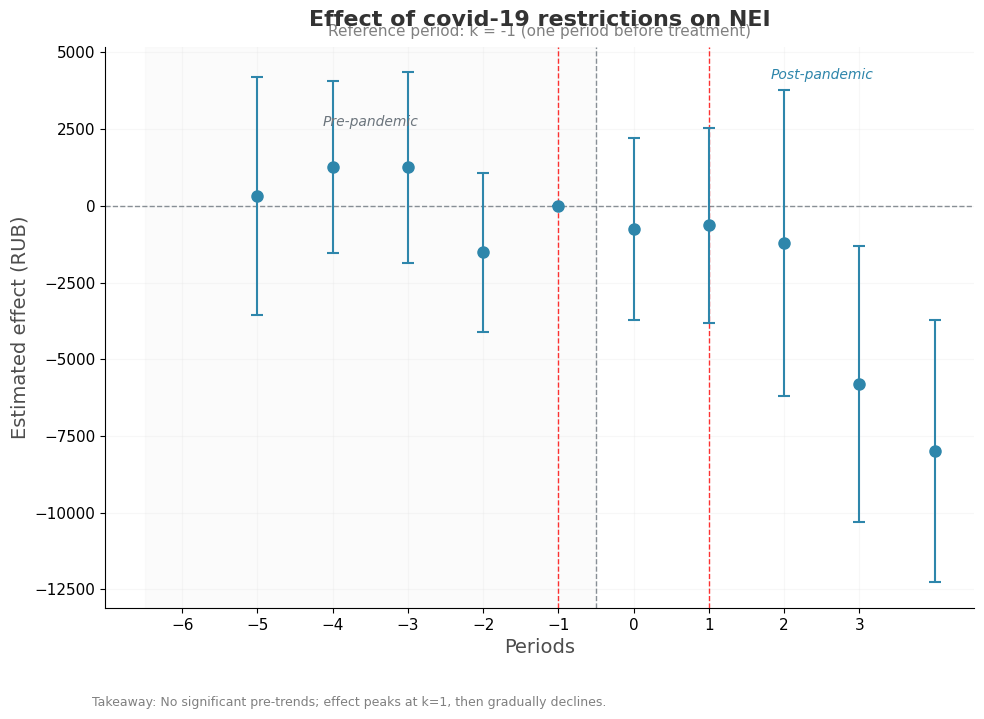

In [90]:
plot_event_margins(event_study_model)

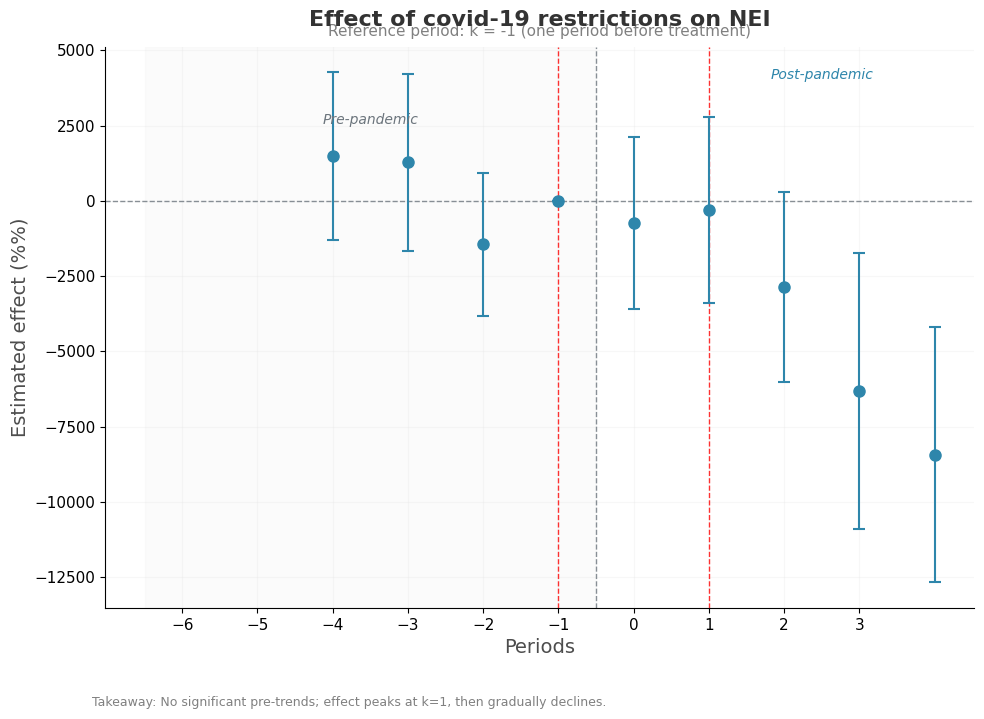

In [91]:
plot_event_margins(event_study_model_reduced, measure_unit='%%')

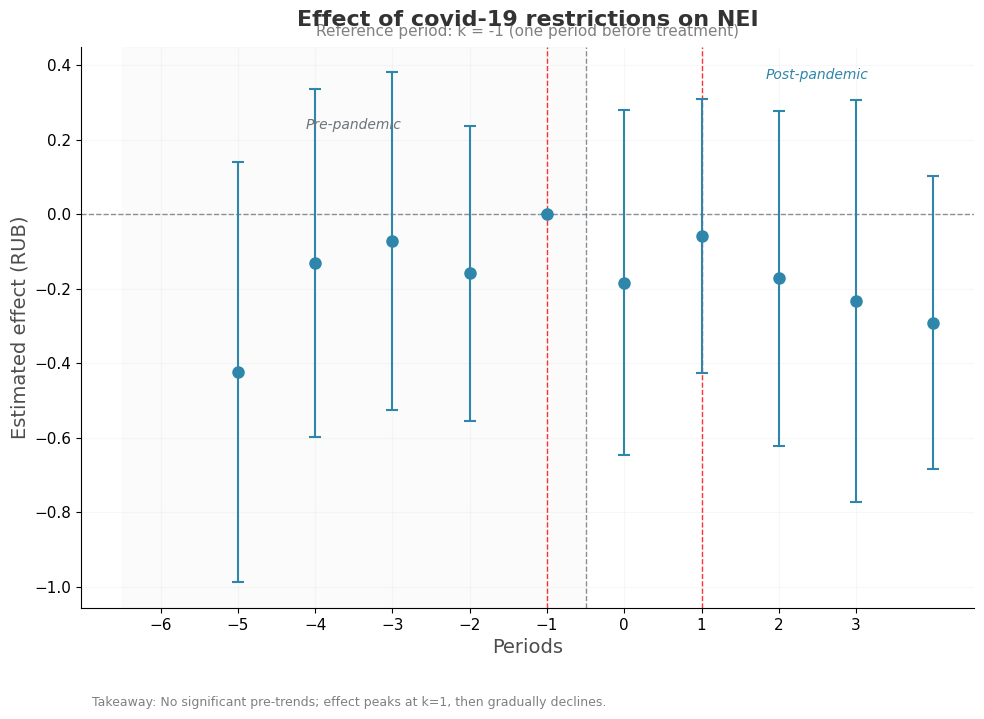

In [92]:
plot_event_margins(event_study_model_log)

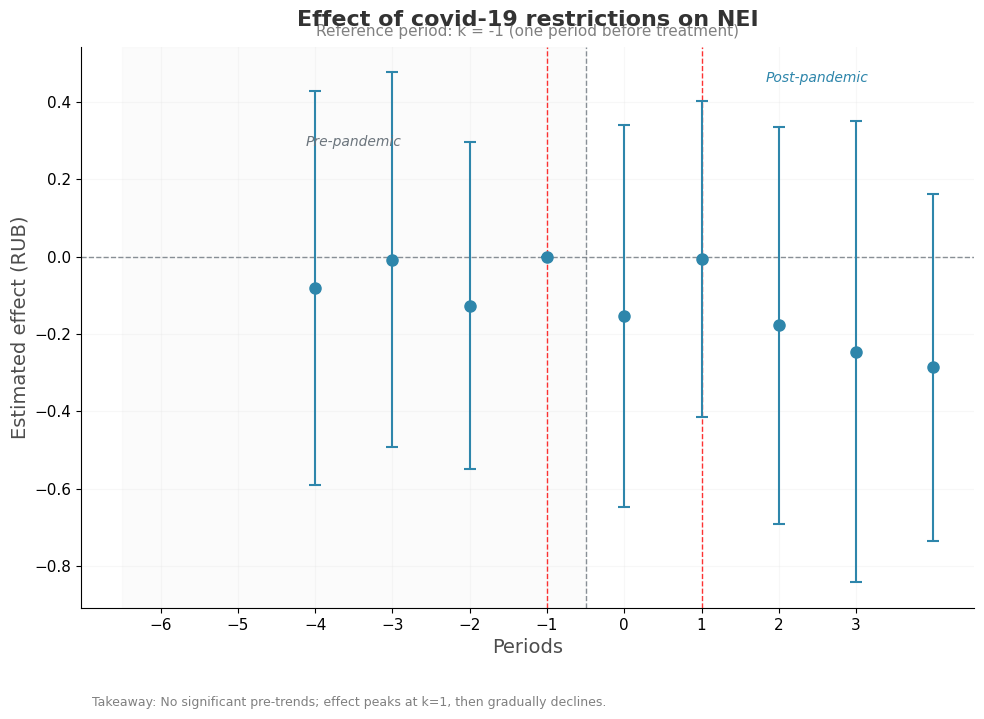

In [93]:
plot_event_margins(event_study_model_reduced_log)

# autocorrelation test

In [94]:
panel_2014_2024 = (
    prepsm_data
        .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(pl.col('period_relevance') > -5)
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

j60  net_job  is_employed_has_disablity   age  \
idind   year                                                            
1.0     2016-01-01  47900.0  47900.0                          0  43.0   
        2018-01-01  47000.0  47000.0                          0  45.0   
        2019-01-01  37000.0  37000.0                          0  46.0   
        2020-01-01  37000.0  37000.0                          0  47.0   
        2021-01-01  70000.0  70000.0                          0  48.0   
...                     ...      ...                        ...   ...   
59398.0 2021-01-01  29000.0  29000.0                          0  37.0   
        2024-01-01  70000.0  70000.0                          0  40.0   
59400.0 2021-01-01  22400.0  12000.0                          0  61.5   
        2024-01-01  41000.0  18000.0                          0  64.5   
59401.0 2024-01-01  50000.0  50000.0                          0  19.5   

                    is_female  is_town  educ_level_school_or_less  \
idind   year                                                        
1.0     2016-01-01          1        1                          0   
        2018-01-01          1        1                          0   
        2019-01-01          1        1                          0   
        2020-01-01          1        1                          0   
        2021-01-01          1        1                          0   
...                       ...      ...                        ...   
59398.0 2021-01-01          1        1                          0   
        2024-01-01          1        1                          0   
59400.0 2021-01-01          1        1                          0   
        2024-01-01          1        1                          0   
59401.0 2024-01-01          1        1                          0   

                    educ_level_common  educ_level_higher  \
idind   year                                               
1.0     2016-01-01                  0                  0   
        2018-01-01                  0                  0   
        2019-01-01                  0                  0   
        2020-01-01                  0                  0   
        2021-01-01                  0                  0   
...                               ...                ...   
59398.0 2021-01-01                  0                  0   
        2024-01-01                  0                  0   
59400.0 2021-01-01                  0                  1   
        2024-01-01                  0                  1   
59401.0 2024-01-01                  1                  0   

                    educ_level_university  ...  chronic_kidney  \
idind   year                               ...                   
1.0     2016-01-01                      1  ...               0   
        2018-01-01                      1  ...               0   
        2019-01-01                      1  ...               0   
        2020-01-01                      1  ...               0   
        2021-01-01                      1  ...               0   
...                                   ...  ...             ...   
59398.0 2021-01-01                      1  ...               0   
        2024-01-01                      1  ...               0   
59400.0 2021-01-01                      0  ...               0   
        2024-01-01                      0  ...               0   
59401.0 2024-01-01                      0  ...               0   

                    chronic_stomach  chronic_spinal  disease_neuro  \
idind   year                                                         
1.0     2016-01-01                0               0              0   
        2018-01-01                0               0              0   
        2019-01-01                0               0              0   
        2020-01-01                0               0              0   
        2021-01-01                0               0              0   
...                             ...           

In [95]:
fe_model = PanelOLS(
    panel_2014_2024_dta['net_job'],
    sm.add_constant(panel_2014_2024_dta[['period_relevance']].astype(float)),
    entity_effects=True
)

fe_resid = fe_model.fit().resids

<Axes: >

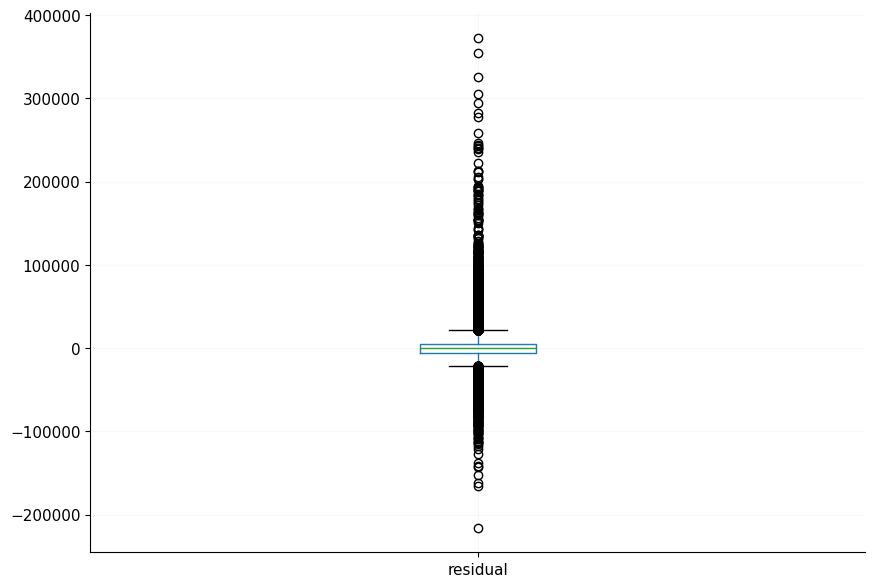

In [96]:
fe_model.fit().resids.to_frame().boxplot(return_type='axes')

In [97]:
fe_model.fit().resids.describe()

count    4.442200e+04
mean    -9.137939e-10
std      1.672555e+04
min     -2.159446e+05
25%     -5.794169e+03
50%     -2.720029e+02
75%      4.996781e+03
max      3.729263e+05
Name: residual, dtype: float64

In [98]:
resid_df = fe_model.fit().resids.to_frame()
resid_df

residual
idind   year                    
1.0     2016-01-01  1.067755e+04
        2018-01-01  3.521020e+03
        2019-01-01 -9.607245e+03
        2020-01-01 -1.273551e+04
        2021-01-01  1.713622e+04
...                          ...
59398.0 2021-01-01 -1.580760e+04
        2024-01-01  1.580760e+04
59400.0 2021-01-01  1.692398e+03
        2024-01-01 -1.692398e+03
59401.0 2024-01-01 -9.167707e-10

[44422 rows x 1 columns]

In [99]:
resid_df['resid_diff'] = resid_df.groupby('idind')['residual'].diff()
resid_df['resid_diff_lag'] = resid_df.groupby('idind')['resid_diff'].shift(1)
resid_df = resid_df.dropna()
resid_df

residual    resid_diff  resid_diff_lag
idind   year                                                  
1.0     2019-01-01  -9607.244966 -13128.265102    -7156.530203
        2020-01-01 -12735.510068  -3128.265102   -13128.265102
        2021-01-01  17136.224831  29871.734898    -3128.265102
        2022-01-01  -8992.040271 -26128.265102    29871.734898
3.0     2019-01-01  -8750.000000 -18528.265102    -5256.530203
...                          ...           ...             ...
59393.0 2023-01-01  11391.734898  21871.734898   -13128.265102
        2024-01-01    663.469797 -10728.265102    21871.734898
59394.0 2022-01-01  -2920.000000    171.734898     5171.734898
        2023-01-01  -2748.265102    171.734898      171.734898
        2024-01-01  17023.469797  19771.734898      171.734898

[29180 rows x 3 columns]

In [100]:
X_test = sm.add_constant(resid_df['resid_diff_lag'])
ols_test = sm.OLS(resid_df['resid_diff'], X_test).fit(cov_type='HC1')
print("\nWooldridge test for serial correlation in panel data:")
print(f"  Coefficient on lagged diff: {ols_test.params.iloc[1]:.4f}")
print(f"  t-statistic: {ols_test.tvalues.iloc[1]:.4f}")
print(f"  p-value: {ols_test.pvalues.iloc[1]:.4f}")


Wooldridge test for serial correlation in panel data:
  Coefficient on lagged diff: -0.4064
  t-statistic: -16.6699
  p-value: 0.0000


# wald test

In [101]:
pre_treatment_terms = [t for t in event_study_terms if int(t.split('_')[2]) < -1]
pre_coefs = event_study_model_reduced.params[pre_treatment_terms].values
pre_vcov = event_study_model_reduced.cov.loc[pre_treatment_terms, pre_treatment_terms].values

In [102]:
q = len(pre_treatment_terms)
wald_stat = pre_coefs @ np.linalg.inv(pre_vcov) @ pre_coefs / q
df_resid = event_study_model_reduced.nobs - event_study_model_reduced.params.shape[0]
p_value = 1 - scipy_stats.f.cdf(wald_stat, q, df_resid)

print(f"\nJoint F-test for pre-treatment coefficients:")
print(f"  F({q}, {df_resid}) = {wald_stat:.4f}")
print(f"  p-value = {p_value:.4f}")


Joint F-test for pre-treatment coefficients:
  F(3, 44414) = 2.1733
  p-value = 0.0889


In [ ]:
(
    prepsm_data
    .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
    .filter(~pl.col('idind').is_in(alike_matched.implode()))
    .filter(pl.col('period_relevance') > -5)
).write_parquet('../data/panel_common_pre_psm_mean3_months_with_add_health_variables_no_outliers.parquet')

In [ ]:
post_psm = pl.read_parquet('../data/panel_common_post_psm_full_mean3_months_with_add_health_variables.parquet').filter(pl.col('is_employed_has_disablity') == 0)#.to_pandas().set_index(['idind', 'year'])
post_psm

In [ ]:
possible_spillovers = post_psm['idind']

In [ ]:
X_agg = post_psm[['is_employed_has_disablity']]
y = post_psm['net_job']

In [ ]:
agg_did_model = PanelOLS(y, X_agg, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(agg_did_model.summary)

In [ ]:
(
    post_psm
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('working_pop') == 1)
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'is_employed_has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='is_employed_has_disablity')

In [ ]:
psm_matched_ids = pl.read_parquet('../data/panel_common_post_psm.parquet')['idind'].unique()
psm_matched_ids.implode()

In [ ]:
(
    panel_common_2019_2020
        .filter(pl.col('idind').is_in(psm_matched_ids.implode()))
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .filter(pl.col('working_pop') == 1)
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='has_disablity')

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv")
df

In [ ]:
df['time_to_treat'] = (
    df['year'].sub(df['_nfd'])
        # missing values for _nfd implies no treatment
        .fillna(0)
        # so we don't have decimals in our factor names
        .astype('int')
)
df

# psm variables

In [ ]:
dictionary = pd.read_excel('../data/variable_dictionary.xlsx')
dictionary

In [ ]:
labels_df = dictionary[['question', 'label']].drop_duplicates()
label_dict = {}

for col, label in zip(labels_df['question'], labels_df['label']):
    label_dict[col] = label
    print(f'{col} : {label}')

In [ ]:
for col, label in zip(labels_df['question'], labels_df['label']):
    if 'disab' in label.lower():
        print(f'{col} : {label}')

In [ ]:
for col, label in zip(labels_df['question'], labels_df['label']):
    if 'm' in col.lower():
        print(f'{col} : {label}')